In [1]:
# =========================
# CELL 1 — IMPORTS
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, roc_auc_score,
    classification_report, confusion_matrix,
    roc_curve, auc, make_scorer
)

In [2]:
# =========================
# CELL 2 — LOAD DATASET
# =========================

df = pd.read_csv(r"D:\college\appliedmaths\Teen_Mental_Health_Dataset.csv")

print(df.head())
print("\nDataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nStatistical Summary:\n", df.describe())

   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9      Instagram          7.4   
1   19  female                       1.9         TikTok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4         TikTok          6.9   
4   15  female                       4.7           Both          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   
3                       1.6                  3.48                0.8   
4                       3.0                  2.37                1.4   

  social_interaction_level  stress_level  anxiety_level  addiction_level  \
0                      low             2              2   


Class Distribution:
depression_label
0    1169
1      31
Name: count, dtype: int64

Imbalance: 1169:31 (97.4% vs 2.6%)


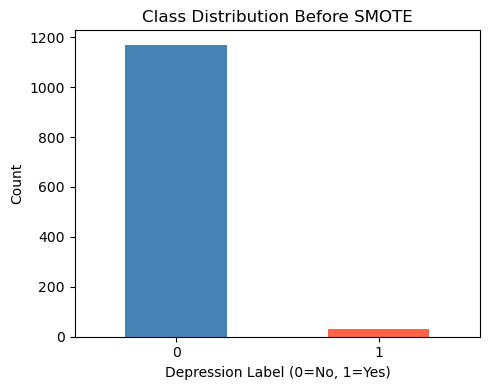

In [3]:
# =========================
# CELL 3 — CLASS DISTRIBUTION
# =========================

counts = df['depression_label'].value_counts()
print("\nClass Distribution:")
print(counts)
print(f"\nImbalance: {counts[0]}:{counts[1]} "
      f"({counts[0]/len(df)*100:.1f}% vs {counts[1]/len(df)*100:.1f}%)")

plt.figure(figsize=(5, 4))
counts.plot(kind='bar', color=['steelblue', 'tomato'])
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Depression Label (0=No, 1=Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
# =========================
# CELL 4 — PREPROCESSING
# =========================

X_full = df.drop(columns=['depression_label'])
y      = df['depression_label']
X_full = pd.get_dummies(X_full, drop_first=True)

print("All features after encoding:", X_full.shape[1])
print(X_full.columns.tolist())

All features after encoding: 14
['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level', 'gender_male', 'platform_usage_Instagram', 'platform_usage_TikTok', 'social_interaction_level_low', 'social_interaction_level_medium']


In [5]:
# =========================
# CELL 5 — TRAIN/TEST SPLIT + SMOTE
# (ALL FEATURES)
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Train (original): {X_train.shape} | "
      f"Depressed: {sum(y_train==1)}, Not: {sum(y_train==0)}")
print(f"Test            : {X_test.shape}  | "
      f"Depressed: {sum(y_test==1)}, Not: {sum(y_test==0)}")
print(f"\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Train (original): (960, 14) | Depressed: 25, Not: 935
Test            : (240, 14)  | Depressed: 6, Not: 234

After SMOTE:
depression_label
0    935
1    935
Name: count, dtype: int64


In [13]:
# =========================
# CELL 6 — BASE DECISION TREE
# (ALL FEATURES)
# =========================

dt_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
dt_model.fit(X_train_smote, y_train_smote)

y_pred  = dt_model.predict(X_test)
y_proba = dt_model.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
f2        = fbeta_score(y_test, y_pred, beta=2, zero_division=0)
roc_auc   = roc_auc_score(y_test, y_proba)

print("=========================")
print("BASE MODEL — ALL FEATURES")
print("=========================")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"F2 Score : {f2:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred,
      target_names=['No Depression', 'Depression'],
      zero_division=0))

BASE MODEL — ALL FEATURES
Accuracy : 0.9708
Precision: 0.4615
Recall   : 1.0000
F1 Score : 0.6316
F2 Score : 0.8108
ROC AUC  : 0.9850

Classification Report:

               precision    recall  f1-score   support

No Depression       1.00      0.97      0.98       234
   Depression       0.46      1.00      0.63         6

     accuracy                           0.97       240
    macro avg       0.73      0.99      0.81       240
 weighted avg       0.99      0.97      0.98       240



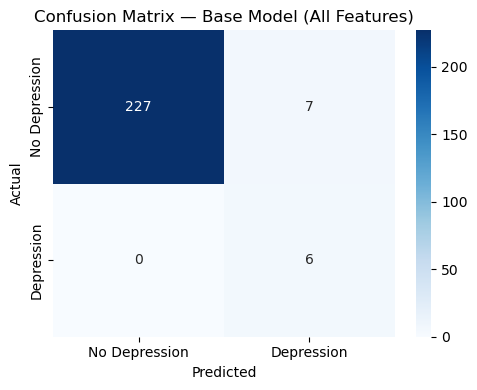

True Positives  (depressed correctly caught): 6
False Negatives (depressed cases missed):     0
False Positives (wrongly flagged):            7
True Negatives  (correctly cleared):          227


In [7]:
# =========================
# CELL 7 — CONFUSION MATRIX
# (BASE MODEL)
# =========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Base Model (All Features)")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (depressed correctly caught): {tp}")
print(f"False Negatives (depressed cases missed):     {fn}")
print(f"False Positives (wrongly flagged):            {fp}")
print(f"True Negatives  (correctly cleared):          {tn}")

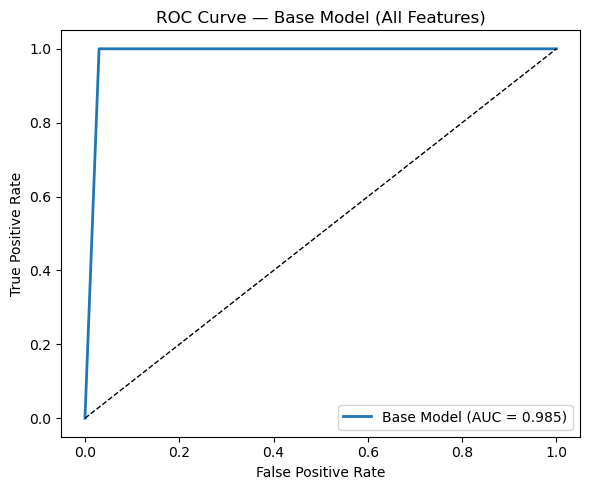

In [8]:
# =========================
# CELL 8 — ROC CURVE
# (BASE MODEL)
# =========================

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2,
         label=f"Base Model (AUC = {roc_auc_val:.3f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Base Model (All Features)")
plt.legend()
plt.tight_layout()
plt.show()

Feature Importance (All Features Model):

                        Feature  Importance
                    sleep_hours    0.507016
                   stress_level    0.327005
                  anxiety_level    0.165640
       screen_time_before_sleep    0.000340
                            age    0.000000
       daily_social_media_hours    0.000000
           academic_performance    0.000000
              physical_activity    0.000000
                addiction_level    0.000000
                    gender_male    0.000000
       platform_usage_Instagram    0.000000
          platform_usage_TikTok    0.000000
   social_interaction_level_low    0.000000
social_interaction_level_medium    0.000000


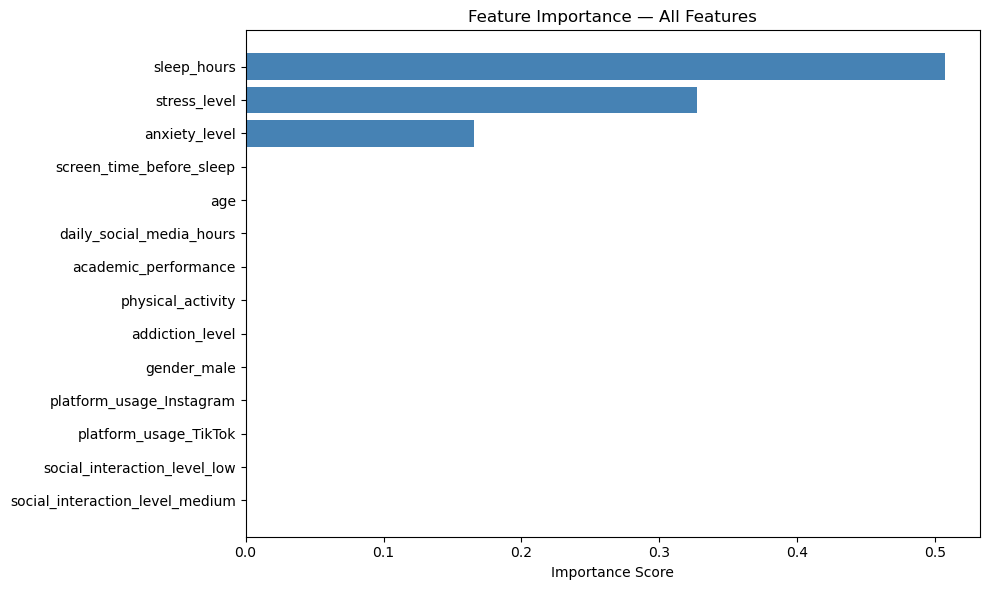

In [14]:
# =========================
# CELL 9 — FEATURE IMPORTANCE
# (BASE MODEL)
# =========================

importance = pd.DataFrame({
    'Feature'   : X_full.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (All Features Model):\n")
print(importance.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'], importance['Importance'], color='steelblue')
plt.xlabel("Importance Score")
plt.title("Feature Importance — All Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

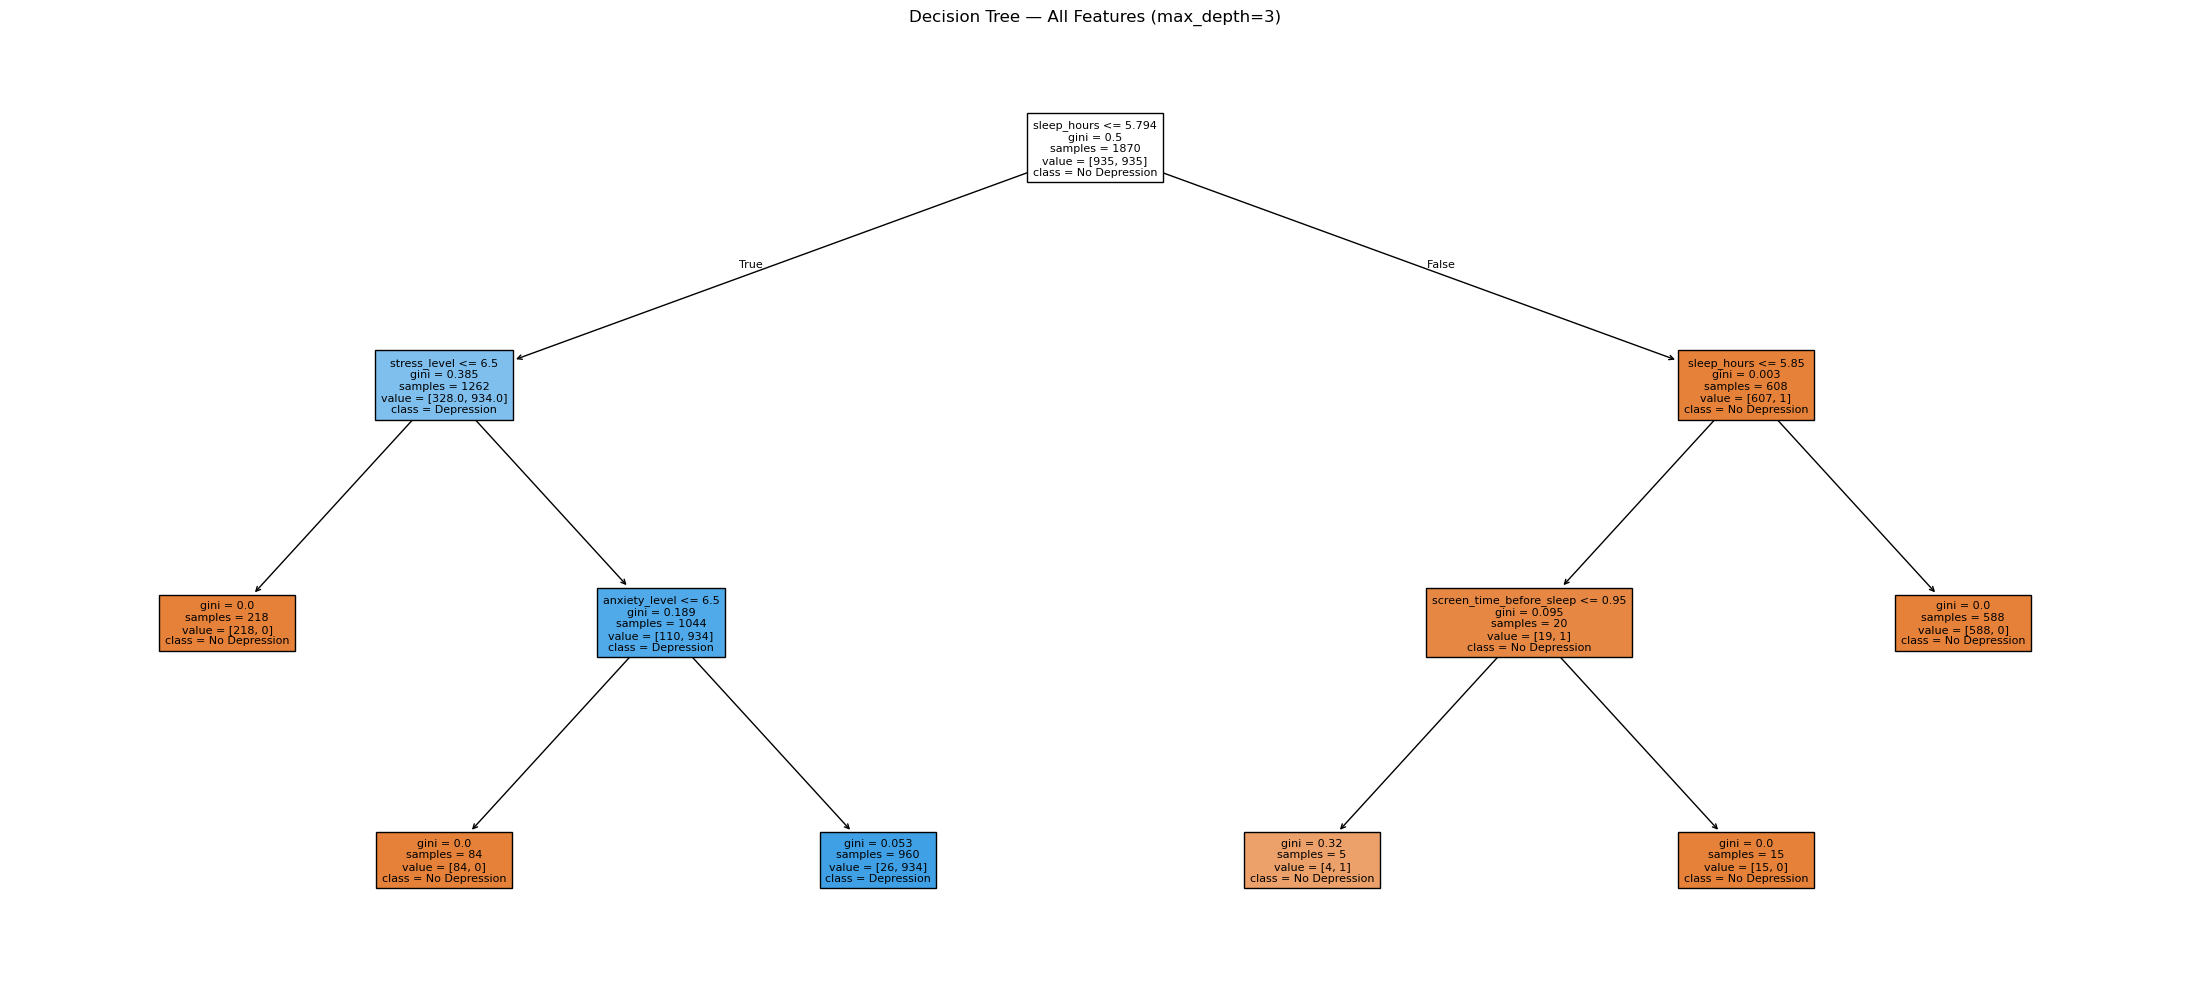

In [15]:
# =========================
# CELL 10 — DECISION TREE VISUALISATION
# (BASE MODEL — ALL FEATURES)
# =========================

plt.figure(figsize=(22, 10))
plot_tree(dt_model,
          feature_names=X_full.columns,
          class_names=['No Depression', 'Depression'],
          filled=True, fontsize=8)
plt.title("Decision Tree — All Features (max_depth=3)")
plt.tight_layout()
plt.show()

In [16]:
# =========================
# CELL 11 — GRIDSEARCHCV
# (ALL FEATURES)
# =========================

param_grid = {
    'max_depth'        : [2, 3, 4],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf' : [3, 5, 10],
    'criterion'        : ['gini', 'entropy'],
    'class_weight'     : ['balanced']
}

f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_smote, y_train_smote)

print("\nBest Parameters:")
print(grid.best_params_)
print(f"\nBest CV F2 Score: {grid.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best Parameters:
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 3, 'min_samples_split': 5}

Best CV F2 Score: 0.9983


In [17]:
# =========================
# CELL 12 — BEST MODEL EVALUATION
# (GRIDSEARCHCV)
# =========================

best_model  = grid.best_estimator_
best_pred   = best_model.predict(X_test)
best_proba  = best_model.predict_proba(X_test)[:, 1]

best_accuracy  = accuracy_score(y_test, best_pred)
best_precision = precision_score(y_test, best_pred, zero_division=0)
best_recall    = recall_score(y_test, best_pred, zero_division=0)
best_f1        = f1_score(y_test, best_pred, zero_division=0)
best_f2        = fbeta_score(y_test, best_pred, beta=2, zero_division=0)
best_roc_auc   = roc_auc_score(y_test, best_proba)

print("=========================")
print("GRIDSEARCHCV BEST MODEL")
print("=========================")
print(f"Accuracy : {best_accuracy:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall   : {best_recall:.4f}")
print(f"F1 Score : {best_f1:.4f}")
print(f"F2 Score : {best_f2:.4f}")
print(f"ROC AUC  : {best_roc_auc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, best_pred,
      target_names=['No Depression', 'Depression'],
      zero_division=0))

GRIDSEARCHCV BEST MODEL
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
F2 Score : 1.0000
ROC AUC  : 1.0000

Classification Report:

               precision    recall  f1-score   support

No Depression       1.00      1.00      1.00       234
   Depression       1.00      1.00      1.00         6

     accuracy                           1.00       240
    macro avg       1.00      1.00      1.00       240
 weighted avg       1.00      1.00      1.00       240



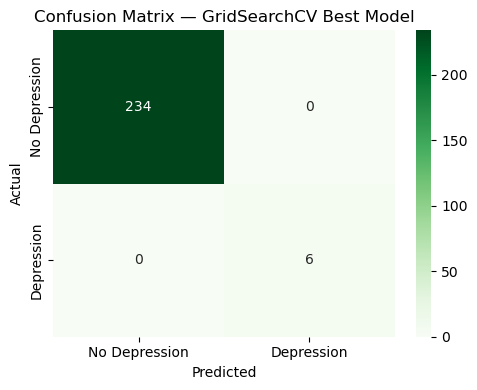

True Positives  (depressed correctly caught): 6
False Negatives (depressed cases missed):     0
False Positives (wrongly flagged):            0
True Negatives  (correctly cleared):          234


In [18]:
# =========================
# CELL 13 — CONFUSION MATRIX
# (GRIDSEARCHCV BEST MODEL)
# =========================

cm_best = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — GridSearchCV Best Model")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_best.ravel()
print(f"True Positives  (depressed correctly caught): {tp}")
print(f"False Negatives (depressed cases missed):     {fn}")
print(f"False Positives (wrongly flagged):            {fp}")
print(f"True Negatives  (correctly cleared):          {tn}")

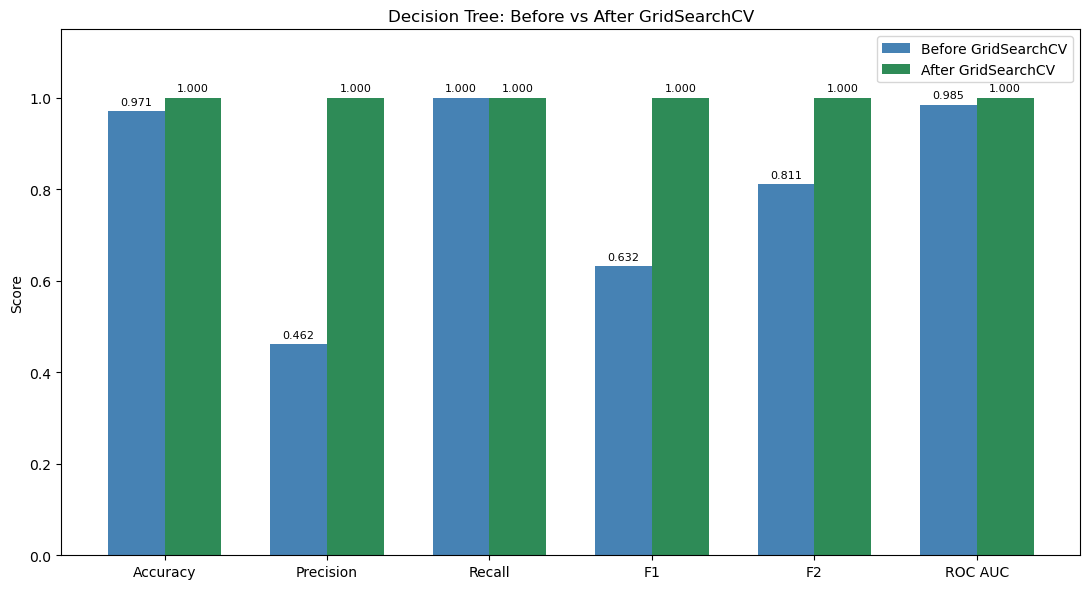

In [19]:
# =========================
# CELL 14 — BEFORE vs AFTER GRIDSEARCHCV
# COMPARISON CHART
# =========================

metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1', 'F2', 'ROC AUC']
before_scores = [accuracy, precision, recall, f1, f2, roc_auc]
after_scores  = [best_accuracy, best_precision,
                 best_recall, best_f1, best_f2, best_roc_auc]

x, w = np.arange(len(metric_names)), 0.35

plt.figure(figsize=(11, 6))
bars1 = plt.bar(x - w/2, before_scores, w,
                label='Before GridSearchCV', color='steelblue')
bars2 = plt.bar(x + w/2, after_scores,  w,
                label='After GridSearchCV',  color='seagreen')

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{bar.get_height():.3f}",
             ha='center', va='bottom', fontsize=8)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{bar.get_height():.3f}",
             ha='center', va='bottom', fontsize=8)

plt.xticks(x, metric_names)
plt.ylabel("Score")
plt.title("Decision Tree: Before vs After GridSearchCV")
plt.ylim(0, 1.15)
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# =========================
# CELL 15 — FEATURE REMOVAL
# SELECT 10 FEATURES
# =========================

selected_features = [
    'sleep_hours',
    'stress_level',
    'anxiety_level',
    'daily_social_media_hours',
    'screen_time_before_sleep',
    'gender_male',
    'addiction_level',
    'academic_performance',
    'physical_activity',
    'age'
]

X_selected = X_full[selected_features]

print("Selected 10 Features:")
for f in selected_features:
    print(f"  - {f}")
print("\nShape:", X_selected.shape)

Selected 10 Features:
  - sleep_hours
  - stress_level
  - anxiety_level
  - daily_social_media_hours
  - screen_time_before_sleep
  - gender_male
  - addiction_level
  - academic_performance
  - physical_activity
  - age

Shape: (1200, 10)


In [23]:
# =========================
# CELL 16 — SELECTED 10 FEATURES MODEL
# =========================

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

smote2 = SMOTE(random_state=42)
X_tr_s2, y_tr_s2 = smote2.fit_resample(X_train_s, y_train_s)

model_sel = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
model_sel.fit(X_tr_s2, y_tr_s2)

y_pred_s  = model_sel.predict(X_test_s)
y_proba_s = model_sel.predict_proba(X_test_s)[:, 1]

sel_accuracy  = accuracy_score(y_test_s, y_pred_s)
sel_precision = precision_score(y_test_s, y_pred_s, zero_division=0)
sel_recall    = recall_score(y_test_s, y_pred_s, zero_division=0)
sel_f1        = f1_score(y_test_s, y_pred_s, zero_division=0)
sel_f2        = fbeta_score(y_test_s, y_pred_s, beta=2, zero_division=0)
sel_roc_auc   = roc_auc_score(y_test_s, y_proba_s)

print("=========================")
print("SELECTED 10 FEATURES MODEL")
print("=========================")
print(f"Accuracy : {sel_accuracy:.4f}")
print(f"Precision: {sel_precision:.4f}")
print(f"Recall   : {sel_recall:.4f}")
print(f"F1 Score : {sel_f1:.4f}")
print(f"F2 Score : {sel_f2:.4f}")
print(f"ROC AUC  : {sel_roc_auc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test_s, y_pred_s,
      target_names=['No Depression', 'Depression'],
      zero_division=0))

SELECTED 10 FEATURES MODEL
Accuracy : 0.9708
Precision: 0.4615
Recall   : 1.0000
F1 Score : 0.6316
F2 Score : 0.8108
ROC AUC  : 0.9850

Classification Report:

               precision    recall  f1-score   support

No Depression       1.00      0.97      0.98       234
   Depression       0.46      1.00      0.63         6

     accuracy                           0.97       240
    macro avg       0.73      0.99      0.81       240
 weighted avg       0.99      0.97      0.98       240



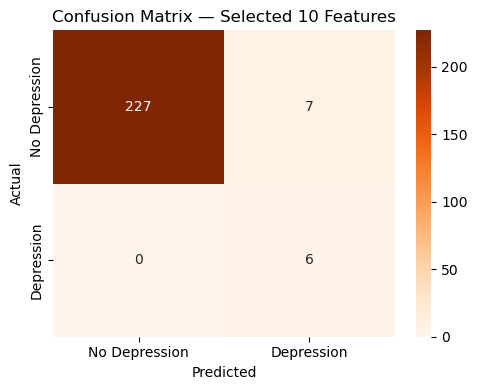

True Positives  (depressed correctly caught): 6
False Negatives (depressed cases missed):     0
False Positives (wrongly flagged):            7
True Negatives  (correctly cleared):          227


In [24]:
# =========================
# CELL 17 — CONFUSION MATRIX
# (SELECTED 10 FEATURES)
# =========================

cm_sel = confusion_matrix(y_test_s, y_pred_s)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_sel, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Selected 10 Features")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_sel.ravel()
print(f"True Positives  (depressed correctly caught): {tp}")
print(f"False Negatives (depressed cases missed):     {fn}")
print(f"False Positives (wrongly flagged):            {fp}")
print(f"True Negatives  (correctly cleared):          {tn}")

Feature Importance (Selected 10 Features):

                 Feature  Importance
             sleep_hours    0.507016
            stress_level    0.327005
           anxiety_level    0.165640
screen_time_before_sleep    0.000340
daily_social_media_hours    0.000000
             gender_male    0.000000
         addiction_level    0.000000
    academic_performance    0.000000
       physical_activity    0.000000
                     age    0.000000


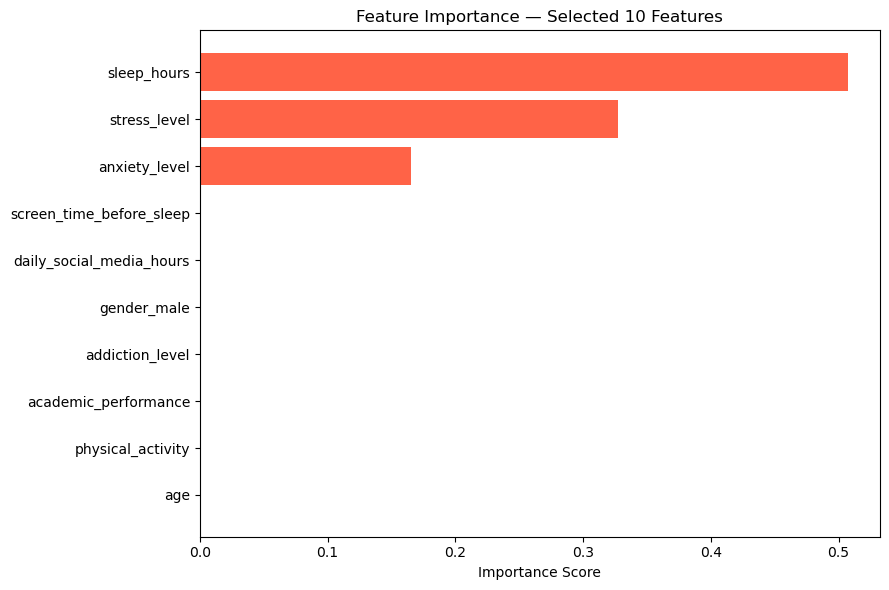

In [25]:
# =========================
# CELL 18 — FEATURE IMPORTANCE
# (SELECTED 10 FEATURES)
# =========================

importance_sel = pd.DataFrame({
    'Feature'   : selected_features,
    'Importance': model_sel.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (Selected 10 Features):\n")
print(importance_sel.to_string(index=False))

plt.figure(figsize=(9, 6))
plt.barh(importance_sel['Feature'], importance_sel['Importance'], color='tomato')
plt.xlabel("Importance Score")
plt.title("Feature Importance — Selected 10 Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

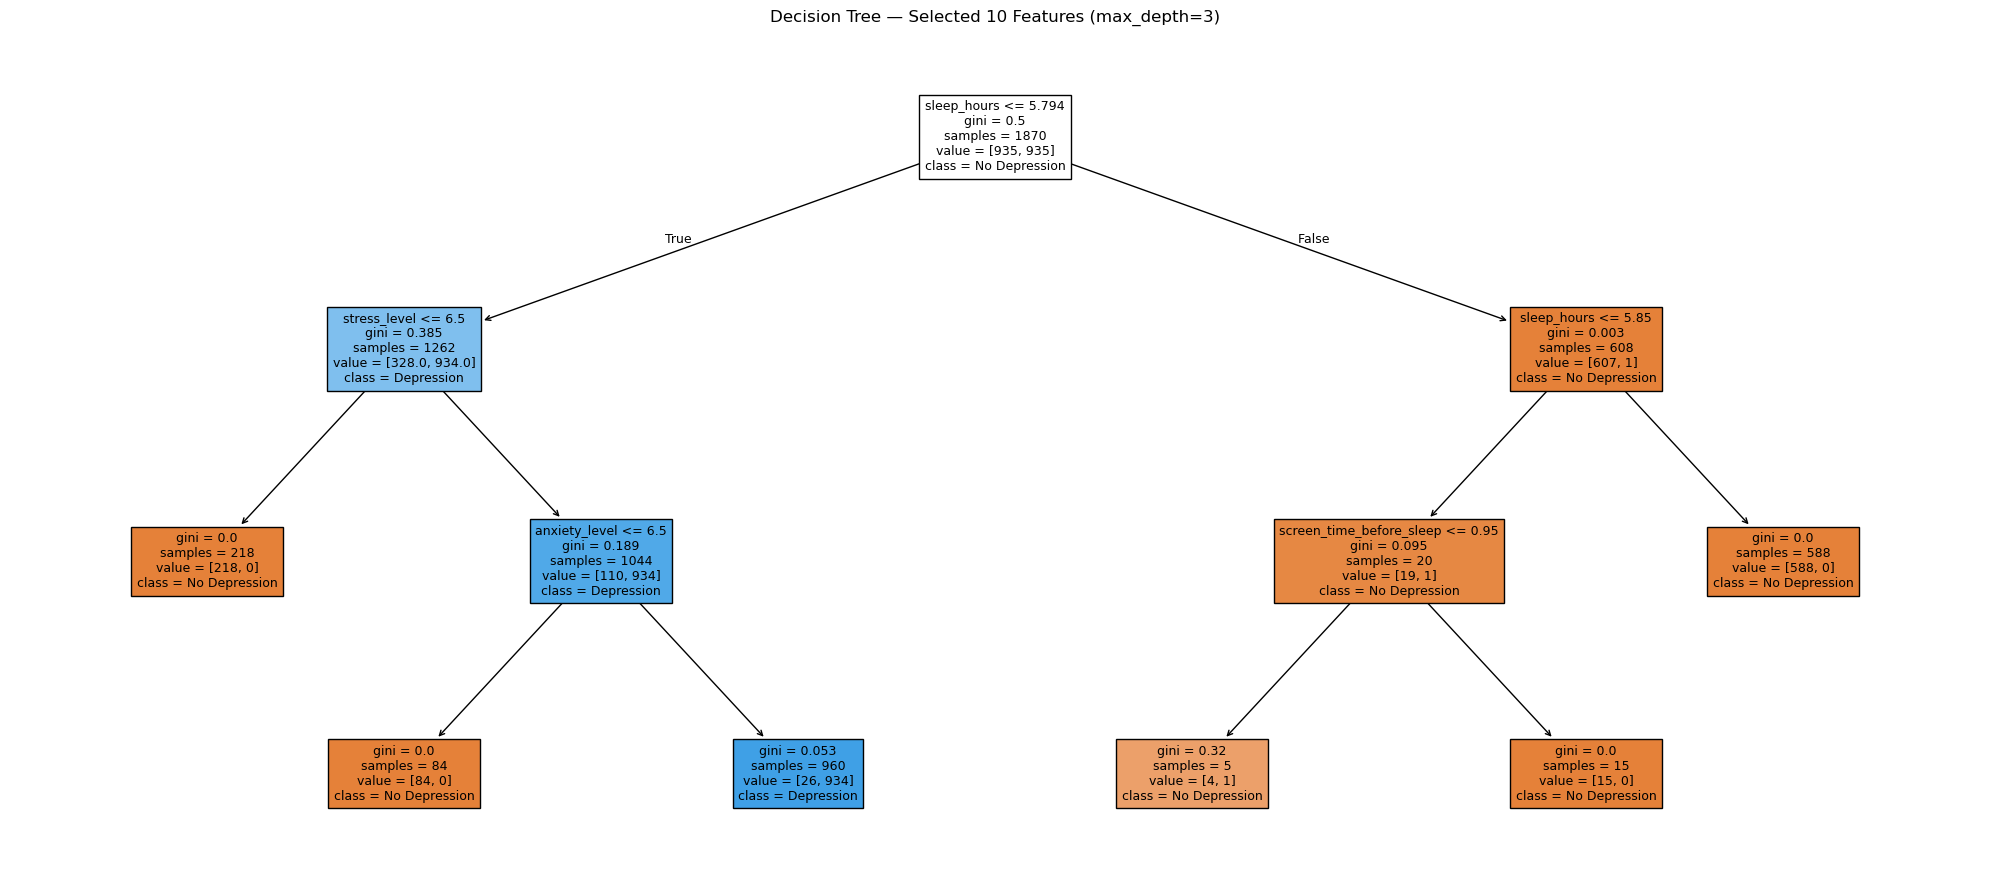

In [26]:
# =========================
# CELL 19 — DECISION TREE VISUALISATION
# (SELECTED 10 FEATURES)
# =========================

plt.figure(figsize=(20, 9))
plot_tree(model_sel,
          feature_names=selected_features,
          class_names=['No Depression', 'Depression'],
          filled=True, fontsize=9)
plt.title("Decision Tree — Selected 10 Features (max_depth=3)")
plt.tight_layout()
plt.show()

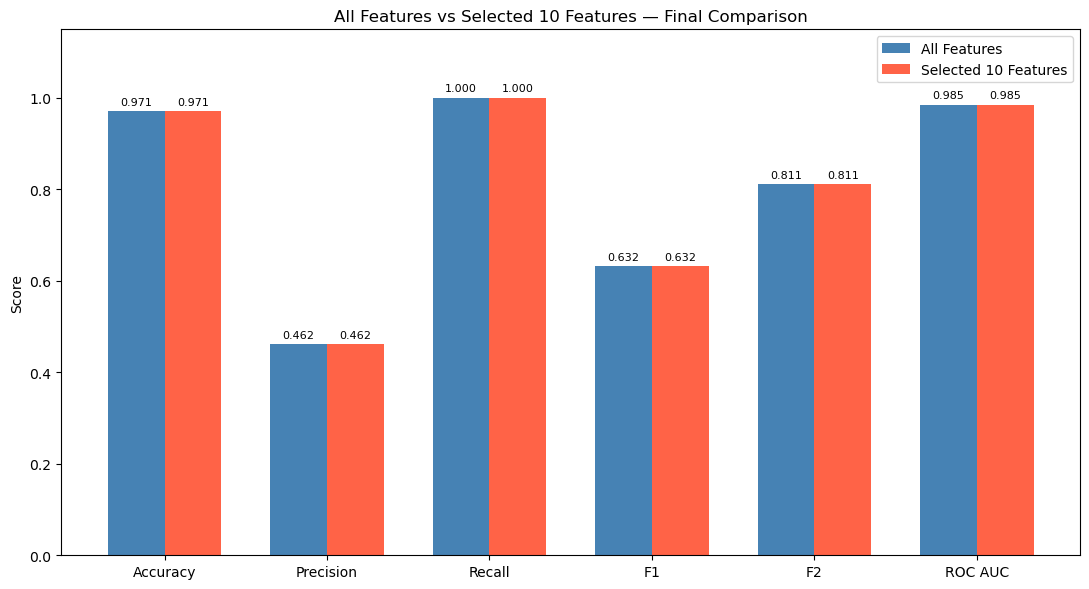


 SUMMARY: All Features vs Selected 10 Features
   Metric  All Features  Selected 10 Only  Difference
 Accuracy        0.9708            0.9708      0.0000
Precision        0.4615            0.4615      0.0000
   Recall        1.0000            1.0000      0.0000
       F1        0.6316            0.6316      0.0000
       F2        0.8108            0.8108      0.0000
  ROC AUC        0.9850            0.9850      0.0000

  F2 change     : +0.0000
  ROC AUC change: +0.0000

  ✅ Selected 10 features perform comparably to all features
     → Simpler model with fewer features is preferred


In [27]:
# =========================
# CELL 20 — ALL FEATURES vs SELECTED 10 FEATURES
# FINAL COMPARISON
# =========================

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'F2', 'ROC AUC']
scores_all   = [accuracy,     precision,     recall,     f1,     f2,     roc_auc]
scores_sel   = [sel_accuracy, sel_precision, sel_recall, sel_f1, sel_f2, sel_roc_auc]

x, w = np.arange(len(metric_names)), 0.35

plt.figure(figsize=(11, 6))
bars1 = plt.bar(x - w/2, scores_all, w,
                label='All Features',        color='steelblue')
bars2 = plt.bar(x + w/2, scores_sel, w,
                label='Selected 10 Features', color='tomato')

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{bar.get_height():.3f}",
             ha='center', va='bottom', fontsize=8)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{bar.get_height():.3f}",
             ha='center', va='bottom', fontsize=8)

plt.xticks(x, metric_names)
plt.ylabel("Score")
plt.title("All Features vs Selected 10 Features — Final Comparison")
plt.ylim(0, 1.15)
plt.legend()
plt.tight_layout()
plt.show()

# --- Summary Table ---
summary = pd.DataFrame({
    'Metric'          : metric_names,
    'All Features'    : scores_all,
    'Selected 10 Only': scores_sel,
    'Difference'      : [s - a for s, a in zip(scores_sel, scores_all)]
})

print("\n" + "="*55)
print(" SUMMARY: All Features vs Selected 10 Features")
print("="*55)
print(summary.to_string(index=False, float_format="{:.4f}".format))

f2_diff  = sel_f2      - f2
auc_diff = sel_roc_auc - roc_auc

print(f"\n  F2 change     : {f2_diff:+.4f}")
print(f"  ROC AUC change: {auc_diff:+.4f}")

if f2_diff >= -0.02:
    print("\n  ✅ Selected 10 features perform comparably to all features")
    print("     → Simpler model with fewer features is preferred")
else:
    print("\n  ⚠️  Performance drops with selected 10 features")
    print("     → Full feature model is preferred")